In [2]:
import numpy as np
import h5py
try:
    from tqdm.auto import tqdm
    TQDM_OK = True
except Exception:
    TQDM_OK = False
import matplotlib.pyplot as plt
from pathlib import Path
import scipy.stats

In [3]:
def angles_like_data(ax, ay, az, bx, by, bz):
    """
    Match data convention:
    - order the two points by z (so dz >= 0)
    - theta_z  = arccos(dz/r)
    - theta_zx = atan2(dx, dz)
    - theta_zy = atan2(dy, dz)
    """
    dz = bz - az
    swap = dz < 0
    if np.any(swap):
        ax2, ay2, az2 = ax.copy(), ay.copy(), az.copy()
        bx2, by2, bz2 = bx.copy(), by.copy(), bz.copy()
        ax2[swap], bx2[swap] = bx2[swap], ax2[swap]
        ay2[swap], by2[swap] = by2[swap], ay2[swap]
        az2[swap], bz2[swap] = bz2[swap], az2[swap]
        ax, ay, az, bx, by, bz = ax2, ay2, az2, bx2, by2, bz2

    dx = bx - ax
    dy = by - ay
    dz = bz - az
    r  = np.sqrt(dx*dx + dy*dy + dz*dz)

    theta_z  = np.arccos(dz / r)
    theta_zx = np.arctan2(dx, dz)
    theta_zy = np.arctan2(dy, dz)
    return theta_z.astype(np.float32), theta_zx.astype(np.float32), theta_zy.astype(np.float32)

In [7]:
def load_data_angles(
    h5_path,
    min_dist=10.0,
    use_centroid=False,
):
    theta_z_real = []
    theta_zx_real = []
    theta_zy_real = []

    with h5py.File(h5_path, "r") as f:
        hits_all = f["normal_hits/data"]
        ref_region = f["normal_hits/ref_region"]

        for evt_idx in range(len(ref_region)):
            start = int(ref_region[evt_idx]["start"])
            stop  = int(ref_region[evt_idx]["stop"])

            if stop <= start:
                continue

            hits = hits_all[start:stop]
            if int(hits["beam_type"][0]) != 0:
                continue
            x = hits["x"]
            y = hits["y"]
            z = hits["z"]
            labels = hits["cluster_id"]

            geom_mask = (
                (y >= -51.85) & (y <= 51.85) &
                (
                    ((z >= 12.68) & (z <= 54.32)) |
                    ((z >= -54.32) & (z <= -12.68))
                )
            )

            idx = np.where(geom_mask & (labels >= 0))[0]
            if idx.size < 2:
                continue

            labs = labels[idx]
            uniq = np.unique(labs)

            if uniq.size != 2:
                continue

            c0 = idx[labs == uniq[0]]
            c1 = idx[labs == uniq[1]]

            if use_centroid:
                x2 = np.array([x[c0].mean(), x[c1].mean()])
                y2 = np.array([y[c0].mean(), y[c1].mean()])
                z2 = np.array([z[c0].mean(), z[c1].mean()])
            else:
                x2 = np.array([x[c0[0]], x[c1[0]]])
                y2 = np.array([y[c0[0]], y[c1[0]]])
                z2 = np.array([z[c0[0]], z[c1[0]]])

            order = np.argsort(z2)
            x2, y2, z2 = x2[order], y2[order], z2[order]

            dx = x2[1] - x2[0]
            dy = y2[1] - y2[0]
            dz = z2[1] - z2[0]

            r = np.sqrt(dx*dx + dy*dy + dz*dz)

            if r < float(min_dist):
                continue

            theta_z_real.append(np.arccos(np.clip(dz / r, -1, 1)))
            theta_zx_real.append(np.arctan2(dx, dz))
            theta_zy_real.append(np.arctan2(dy, dz))

    return (
        np.asarray(theta_z_real, dtype=np.float32),
        np.asarray(theta_zx_real, dtype=np.float32),
        np.asarray(theta_zy_real, dtype=np.float32),
    )

In [24]:
min_dist = 10.0
theta_z_real, theta_zx_real, theta_zy_real = load_data_angles(
    "../data/normal_hits_ref_region_data.h5",
    min_dist=min_dist,
    use_centroid=True,   # try True later!
)
print("Data doublets:", len(theta_z_real), " (new clusters)")


Data doublets: 9489  (new clusters)


In [9]:
def build_doublet_arrays_from_cluster_pairs(cluster_pairs, min_dist=10.0, sort_by_z=True):
    dx, dy, dz = [], [], []
    theta_z, theta_zx, theta_zy = [], [], []
    e0, e1, esum, eabsdiff = [], [], [], []
    npts0, npts1 = [], []

    for c0, c1 in cluster_pairs:
        p0 = np.array([c0["x"], c0["y"], c0["z"]], dtype=float)
        p1 = np.array([c1["x"], c1["y"], c1["z"]], dtype=float)
        if sort_by_z and (p1[2] < p0[2]):
            p0, p1 = p1, p0
            c0, c1 = c1, c0

        d = p1 - p0
        dist = np.linalg.norm(d)
        if dist < float(min_dist):
            continue

        dx.append(d[0]); dy.append(d[1]); dz.append(d[2])
        theta_z.append(np.arccos(np.clip(d[2] / dist, -1.0, 1.0)))
        theta_zx.append(np.arctan2(d[0], d[2]))
        theta_zy.append(np.arctan2(d[1], d[2]))

        ee0 = c0.get("energy", np.nan)
        ee1 = c1.get("energy", np.nan)
        e0.append(ee0); e1.append(ee1)
        esum.append(ee0 + ee1 if np.isfinite(ee0) and np.isfinite(ee1) else np.nan)
        eabsdiff.append(abs(ee1 - ee0) if np.isfinite(ee0) and np.isfinite(ee1) else np.nan)
        npts0.append(c0.get("npts", np.nan)); npts1.append(c1.get("npts", np.nan))

    return {
        "dx": np.asarray(dx), "dy": np.asarray(dy), "dz": np.asarray(dz),
        "theta_z": np.asarray(theta_z), "theta_zx": np.asarray(theta_zx), "theta_zy": np.asarray(theta_zy),
        "e0": np.asarray(e0, dtype=float), "e1": np.asarray(e1, dtype=float),
        "esum": np.asarray(esum, dtype=float), "eabsdiff": np.asarray(eabsdiff, dtype=float),
        "npts0": np.asarray(npts0, dtype=float), "npts1": np.asarray(npts1, dtype=float),
    }


def monte_carlo_doublets_from_singles(single_clusters, n_accept=100_000, min_dist=10.0, sort_by_z=True,
                                      seed=1234, allow_same_source_event=True, max_trials_factor=50):
    """
    Build synthetic doublets by independently drawing from the observed single-cluster pool.
    """
    rng = np.random.default_rng(seed)
    singles = list(single_clusters)
    if len(singles) < 2:
        raise ValueError("Need at least two single clusters to build a singles-driven MC.")

    accepted_pairs = []
    trials = 0
    max_trials = int(max_trials_factor * n_accept)

    while len(accepted_pairs) < n_accept and trials < max_trials:
        trials += 1
        i0 = rng.integers(0, len(singles))
        i1 = rng.integers(0, len(singles) - 1)
        if i1 >= i0:
            i1 += 1
        c0 = singles[i0]
        c1 = singles[i1]

        if (not allow_same_source_event) and (c0["event_key"] == c1["event_key"]):
            continue

        p0 = np.array([c0["x"], c0["y"], c0["z"]], dtype=float)
        p1 = np.array([c1["x"], c1["y"], c1["z"]], dtype=float)
        if np.linalg.norm(p1 - p0) < float(min_dist):
            continue

        accepted_pairs.append((c0, c1))

    if len(accepted_pairs) < n_accept:
        print(f"Warning: requested {n_accept} accepted singles-MC doublets, got {len(accepted_pairs)}")

    return build_doublet_arrays_from_cluster_pairs(accepted_pairs, min_dist=min_dist, sort_by_z=sort_by_z)


In [10]:
SINGLE_ENERGY_KEYS = [
    "energy", "E", "adc", "adcs", "q", "Q", "charge", "charges", "dq", "de", "nhit", "nhits"
]
def fiducial_geom_mask_from_arrays(x, y, z):
    return (
        (y >= -51.85) & (y <= 51.85) &
        (((z >= 12.68) & (z <= 54.32)) | ((z >= -54.32) & (z <= -12.68)))
    )


def infer_cluster_energy(event_group, cluster_indices, candidate_keys=SINGLE_ENERGY_KEYS):
    """
    Best-effort cluster energy / charge estimator.

    Returns the sum over the first charge-like dataset found in the event group.
    If nothing suitable is present, returns np.nan.
    """
    n_points = len(event_group["x"])

    for key in candidate_keys:
        if key not in event_group:
            continue

        arr = event_group[key][:]
        arr = np.asarray(arr)

        # Per-point quantity: sum over hits in the cluster
        if arr.ndim == 1 and len(arr) == n_points:
            try:
                return float(np.nansum(arr[cluster_indices]))
            except Exception:
                pass

        # Already one value per event / cluster-like array — not safe to assume mapping here
        # so we skip it rather than risk a wrong interpretation.

    return np.nan

def load_cluster_event_summary(h5_path, use_centroid=True):
    """
    Parse all events from normal_hits/ref_region.

    Returns:
      multiplicities
      singles
      doublets
      triplets
      all_clusters
      event_windows_s (empty)
    """
    multiplicities = []
    singles = []
    doublets = []
    triplets = []
    all_clusters = []
    event_windows_s = []

    with h5py.File(h5_path, "r") as f:

        hits_all = f["normal_hits/data"]
        ref_region = f["normal_hits/ref_region"]

        iterable = (
            tqdm(range(len(ref_region)),
                 desc=f"Summarizing {Path(h5_path).name}")
            if TQDM_OK else range(len(ref_region))
        )

        for evt_idx in iterable:

            start = int(ref_region[evt_idx]["start"])
            stop  = int(ref_region[evt_idx]["stop"])

            if stop <= start:
                multiplicities.append(0)
                continue
            
            hits = hits_all[start:stop]

            
            if int(hits["beam_type"][0]) != 0:
                continue

                
            x = hits["x"].astype(float)
            y = hits["y"].astype(float)
            z = hits["z"].astype(float)
            labels = hits["cluster_id"]

            geom_mask = fiducial_geom_mask_from_arrays(x, y, z)

            idx = np.where(geom_mask & (labels >= 0))[0]

            if len(idx) == 0:
                multiplicities.append(0)
                continue

            labs = labels[idx]
            uniq = np.unique(labs)

            clusters = []

            for lab in uniq:

                cidx = idx[labs == lab]

                if use_centroid:
                    pos = np.array([
                        x[cidx].mean(),
                        y[cidx].mean(),
                        z[cidx].mean()
                    ])
                else:
                    pos = np.array([
                        x[cidx[0]],
                        y[cidx[0]],
                        z[cidx[0]]
                    ])

                energy = np.sum(hits["Q"][cidx])

                cluster = {
                    "event_key": evt_idx,
                    "label": int(lab),
                    "npts": int(len(cidx)),
                    "x": float(pos[0]),
                    "y": float(pos[1]),
                    "z": float(pos[2]),
                    "energy": float(energy),
                }

                clusters.append(cluster)
                all_clusters.append(cluster)

            multiplicities.append(len(clusters))

            if len(clusters) == 1:
                singles.append(clusters[0])
            elif len(clusters) == 2:
                doublets.append(clusters)
            elif len(clusters) == 3:
                triplets.append(clusters)

    return {
        "multiplicities": np.asarray(multiplicities, dtype=int),
        "singles": singles,
        "doublets": doublets,
        "triplets": triplets,
        "all_clusters": all_clusters,
        "event_windows_s": np.asarray(event_windows_s, dtype=float),
    }

In [25]:
summary_new = load_cluster_event_summary("../data/normal_hits_ref_region_data.h5", use_centroid=True)

print("New clustering:")
print("  total events   =", len(summary_new["multiplicities"]))
print("  singles pool   =", len(summary_new["singles"]))
print("  doublets       =", len(summary_new["doublets"]))
print("  triplets       =", len(summary_new["triplets"]))


Summarizing normal_hits_ref_region_data.h5:   0%|          | 0/55876 [00:00<?, ?it/s]

New clustering:
  total events   = 49835
  singles pool   = 12390
  doublets       = 9995
  triplets       = 6002


In [26]:
obs_doublets_new = build_doublet_arrays_from_cluster_pairs(summary_new["doublets"], min_dist=min_dist, sort_by_z=True)
print("Observed clustering doublets after min_dist:", len(obs_doublets_new["dx"]))

Observed clustering doublets after min_dist: 9489


In [27]:
SINGLES_MC_TARGET = 200_000  
singles_mc_new = monte_carlo_doublets_from_singles(
    summary_new["singles"],
    n_accept=SINGLES_MC_TARGET,
    min_dist=min_dist,
    sort_by_z=True,
    seed=10,
    allow_same_source_event=False,
)



print("Singles-driven MC (singles pool):", len(singles_mc_new["dx"]))

Singles-driven MC (singles pool): 200000


In [20]:
def chi2_ndf_pvalue_from_hists(data_counts, model_counts, n_fit_params=1, min_variance=1.0):
    """
    Simple binned chi2 using Poisson data variance.

    Parameters
    ----------
    data_counts : array-like
        Observed bin counts.
    model_counts : array-like
        Expected / model bin counts, already normalized as desired.
    n_fit_params : int
        Number of fitted parameters to subtract from NDF.
        Use 1 when the model is normalized to the data.
    min_variance : float
        Floor for the variance to avoid divide-by-zero in empty bins.

    Returns
    -------
    chi2, ndf, pval, mask
    """
    data_counts = np.asarray(data_counts, dtype=float)
    model_counts = np.asarray(model_counts, dtype=float)

    # Keep bins where at least one side has content
    mask = (data_counts > 0) | (model_counts > 0)
    if not np.any(mask):
        return np.nan, 0, np.nan, mask

    d = data_counts[mask]
    m = model_counts[mask]
    var = np.maximum(d, float(min_variance))

    chi2 = float(np.sum((d - m)**2 / var))
    ndf = int(mask.sum() - n_fit_params)
    if ndf <= 0:
        return chi2, ndf, np.nan, mask

    pval = float(scipy.stats.chi2.sf(chi2, ndf))
    return chi2, ndf, pval, mask

def _stats_label(chi2, ndf, pval):
    if not np.isfinite(chi2) or ndf <= 0 or not np.isfinite(pval):
        return "chi2/ndf = n/a, p = n/a"
    return fr"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf} = {chi2/ndf:.2f}$,  $p = {pval:.3g}$"
def overlay_hist_simple(
    data_a, data_b, label_a, label_b, title, xlabel,
    bins=60, density=True, range=None, annotate_stats=True
):
    a = np.asarray(data_a)
    b = np.asarray(data_b)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if len(a) == 0 or len(b) == 0:
        print(f"Skipping {title}: one of the inputs is empty.")
        return

    # Common binning from the union of both samples
    if range is None:
        allv = np.concatenate([a, b])
        range = (float(np.min(allv)), float(np.max(allv)))

    counts_a, edges = np.histogram(a, bins=bins, range=range)
    counts_b, _ = np.histogram(b, bins=edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    # Scale model / MC to the observed total count for chi2 and visual comparison
    scale_b = counts_a.sum() / max(counts_b.sum(), 1)
    model_b = counts_b.astype(float) * scale_b

    chi2, ndf, pval, _ = chi2_ndf_pvalue_from_hists(counts_a, model_b, n_fit_params=1)

    # Plot as normalized counts or raw counts, but always with Poisson data bars
    if density:
        norm_a = max(len(a), 1) * widths
        norm_b = max(len(b), 1) * widths
        y_a = counts_a / norm_a
        yerr_a = np.sqrt(counts_a) / norm_a
        y_b = counts_b / norm_b
        ylabel = "normalized counts"
    else:
        y_a = counts_a.astype(float)
        yerr_a = np.sqrt(counts_a)
        y_b = model_b
        ylabel = "counts"

    plt.figure(figsize=(7, 5))
    plt.errorbar(
        centers, y_a, yerr=yerr_a, fmt="o", markersize=4, capsize=2,
        label=f"{label_a} | {_stats_label(chi2, ndf, pval)}"
    )

    if density:
        plt.hist(
            b, bins=edges, density=True, histtype="step", linewidth=2,
            linestyle="--", label=label_b
        )
    else:
        plt.step(edges[:-1], y_b, where="post", linestyle="--", linewidth=2, label=label_b)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(fontsize=9)
    plt.tight_layout()
    #save_current_figure(title)
    plt.show()

    print(f"{title}")
    print(f"  {_stats_label(chi2, ndf, pval)}")


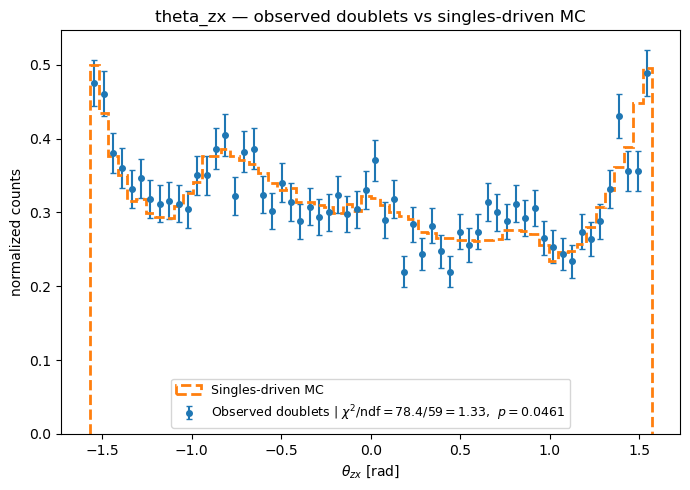

theta_zx — observed doublets vs singles-driven MC
  $\chi^2/\mathrm{ndf} = 78.4/59 = 1.33$,  $p = 0.0461$


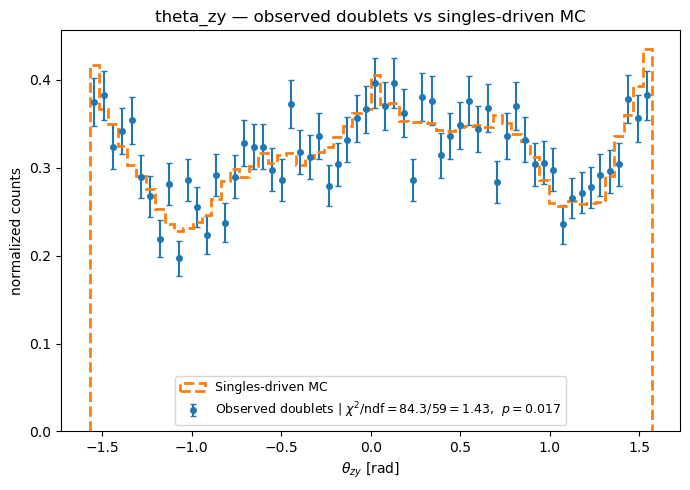

theta_zy — observed doublets vs singles-driven MC
  $\chi^2/\mathrm{ndf} = 84.3/59 = 1.43$,  $p = 0.017$


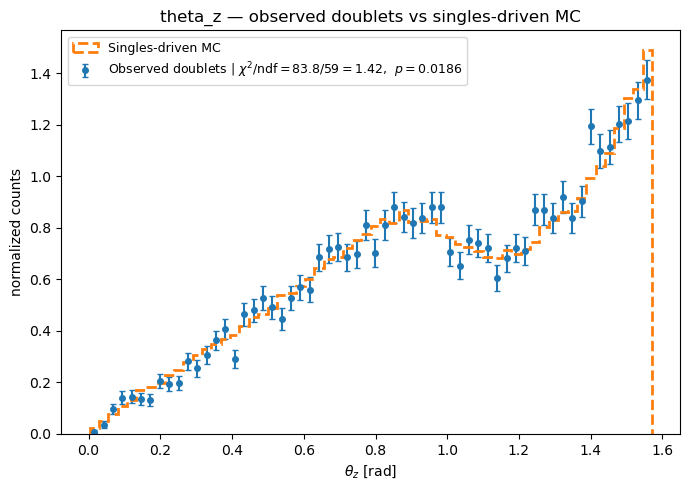

theta_z — observed doublets vs singles-driven MC
  $\chi^2/\mathrm{ndf} = 83.8/59 = 1.42$,  $p = 0.0186$


In [28]:
overlay_hist_simple(
    obs_doublets_new["theta_zx"], singles_mc_new["theta_zx"],
    "Observed doublets", "Singles-driven MC",
    title="theta_zx — observed doublets vs singles-driven MC",
    xlabel=r"$\theta_{zx}$ [rad]", bins=60,
)

overlay_hist_simple(
    obs_doublets_new["theta_zy"], singles_mc_new["theta_zy"],
    "Observed doublets", "Singles-driven MC",
    title="theta_zy — observed doublets vs singles-driven MC",
    xlabel=r"$\theta_{zy}$ [rad]", bins=60,
)

overlay_hist_simple(
    obs_doublets_new["theta_z"], singles_mc_new["theta_z"],
    "Observed doublets", "Singles-driven MC",
    title="theta_z — observed doublets vs singles-driven MC",
    xlabel=r"$\theta_{z}$ [rad]", bins=60,
)



Energy/size comparison for new clustering


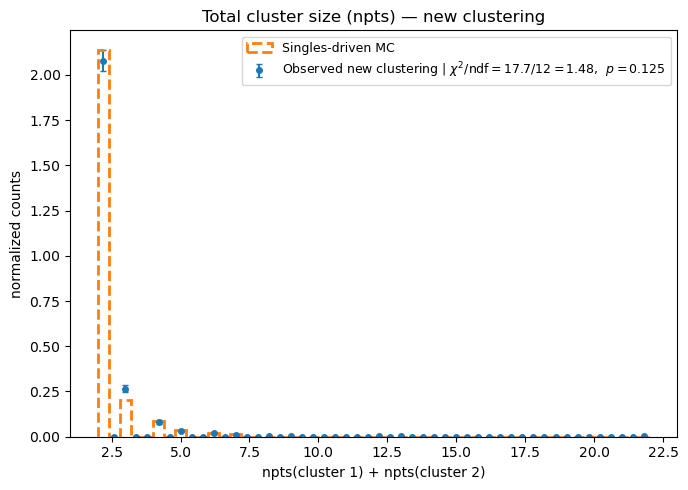

Total cluster size (npts) — new clustering
  $\chi^2/\mathrm{ndf} = 17.7/12 = 1.48$,  $p = 0.125$


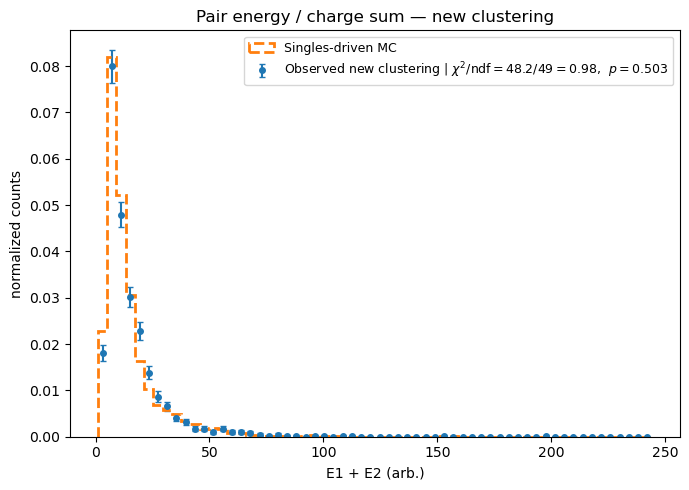

Pair energy / charge sum — new clustering
  $\chi^2/\mathrm{ndf} = 48.2/49 = 0.98$,  $p = 0.503$


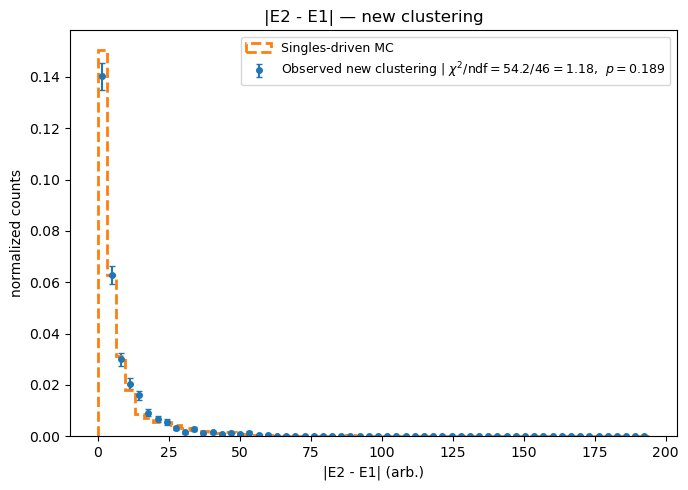

|E2 - E1| — new clustering
  $\chi^2/\mathrm{ndf} = 54.2/46 = 1.18$,  $p = 0.189$


In [17]:
for label, obs, smc in [
    ("new clustering", obs_doublets_new, singles_mc_new),
]:
    print(f"\nEnergy/size comparison for {label}")

    overlay_hist_simple(
        obs["npts0"] + obs["npts1"], smc["npts0"] + smc["npts1"],
        f"Observed {label}", "Singles-driven MC",
        title=f"Total cluster size (npts) — {label}",
        xlabel="npts(cluster 1) + npts(cluster 2)", bins=50,
    )

    if np.isfinite(obs["esum"]).sum() > 0 and np.isfinite(smc["esum"]).sum() > 0:
        overlay_hist_simple(
            obs["esum"], smc["esum"],
            f"Observed {label}", "Singles-driven MC",
            title=f"Pair energy / charge sum — {label}",
            xlabel="E1 + E2 (arb.)", bins=60,
        )
        overlay_hist_simple(
            obs["eabsdiff"], smc["eabsdiff"],
            f"Observed {label}", "Singles-driven MC",
            title=f"|E2 - E1| — {label}",
            xlabel="|E2 - E1| (arb.)", bins=60,
        )
    else:
        print("  No usable per-cluster energy / charge field found; skipping energy plots.")